# Advanced Energy Demand Forecasting using LSTM
In this notebook, we utilize the true power of LSTMs by feeding data in **sequences** (e.g., a rolling window of the past 24 hours). We also include time-based features (hour, day of week) and train for more epochs to achieve higher accuracy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

### 1. Load Data and Visualize Features

In [2]:
# Load the fully processed dataset
df = pd.read_csv('../data/processed/eia_with_features.csv', parse_dates=['datetime_utc'])
df = df.dropna() # Drop rows with missing values

# Focus on PJM region
region_data = df[df['region'] == 'PJM'].copy()
region_data.set_index('datetime_utc', inplace=True)
region_data = region_data.sort_index()

print(f"Data shape for PJM: {region_data.shape}")

Data shape for PJM: (8019, 15)


### 2. Data Normalization and Train/Test Split

In [3]:
# Let's include context features: hour, day_of_week, month
# And weather: temperature, humidity
features = ['temperature_F', 'humidity_pct', 'hour', 'day_of_week', 'month', 'demand_lag_1h', 'demand_lag_24h']
target = 'demand_mwh'

X = region_data[features].values
y = region_data[target].values.reshape(-1, 1)

# Normalize the data
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Split into train and test sets (80% train, 20% test)
train_size = int(len(X_scaled) * 0.8)

X_train_raw, X_test_raw = X_scaled[:train_size], X_scaled[train_size:]
y_train_raw, y_test_raw = y_scaled[:train_size], y_scaled[train_size:]

### 3. Create Rolling Sequences for LSTM
This is the core of an LSTM. Instead of feeding 1 hour at a time, we feed a window of `seq_length` hours (e.g. 24 hours) to predict the next hour.

In [4]:
def create_sequences(X, y, seq_length=24):
    xs, ys = [], []
    for i in range(len(X) - seq_length):
        xs.append(X[i:(i + seq_length)])
        ys.append(y[i + seq_length])
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 24

X_train_seq, y_train_seq = create_sequences(X_train_raw, y_train_raw, SEQ_LENGTH)
X_test_seq, y_test_seq = create_sequences(X_test_raw, y_test_raw, SEQ_LENGTH)

print(f"X_train Sequence Shape: {X_train_seq.shape} -> (samples, sequence_length, features)")

# Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32)

# Create DataLoaders
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

X_train Sequence Shape: (6391, 24, 7) -> (samples, sequence_length, features)


### 4. Build the True LSTM Model in PyTorch

In [5]:
class TrueEnergyLSTM(nn.Module):
    def __init__(self, input_size, hidden_layer_size=64, num_layers=2, output_size=1):
        super(TrueEnergyLSTM, self).__init__()
        self.hidden_layer_size = hidden_layer_size
        
        # LSTM layer with multiple layers for deeper learning
        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers=num_layers, batch_first=True, dropout=0.2)
        
        # Fully connected output layer
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        # lstm_out shape: (batch_size, seq_len, hidden_size)
        lstm_out, _ = self.lstm(input_seq)
        
        # We only want the output from the final time step in the sequence to predict the next value
        last_time_step_out = lstm_out[:, -1, :]
        
        predictions = self.linear(last_time_step_out)
        return predictions

input_size = len(features)
model = TrueEnergyLSTM(input_size=input_size)

loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

TrueEnergyLSTM(
  (lstm): LSTM(7, 64, num_layers=2, batch_first=True, dropout=0.2)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)


### 5. Train the Model
Training for 50 epochs allows the neural network to adjust its weights more thoroughly over time.

Epoch  1 | Loss: 0.05226


Epoch  5 | Loss: 0.03938


Epoch 10 | Loss: 0.03567


Epoch 15 | Loss: 0.03363


Epoch 20 | Loss: 0.03077


...

Epoch 30 | Loss: 0.02676


Epoch 35 | Loss: 0.02275


Epoch 40 | Loss: 0.01832


Epoch 45 | Loss: 0.01597


Epoch 50 | Loss: 0.01304


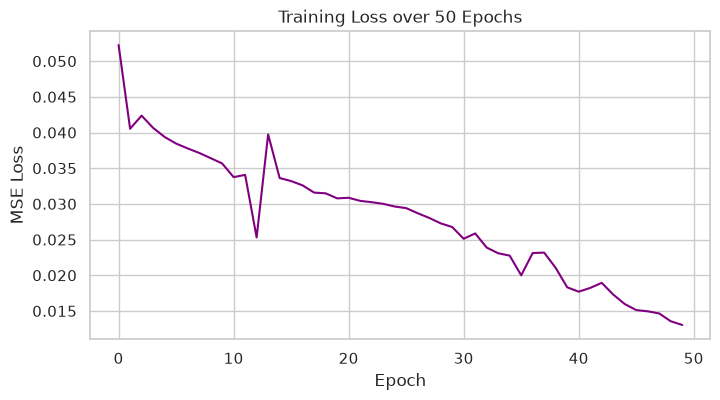

In [6]:
epochs = 50
losses = []

for i in range(epochs):
    epoch_loss = 0
    for seq, labels in train_loader:
        optimizer.zero_grad()
        
        y_pred = model(seq)
        
        single_loss = loss_function(y_pred, labels)
        single_loss.backward()
        optimizer.step()
        
        epoch_loss += single_loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    if (i+1) % 5 == 0 or i == 0:
        print(f'Epoch {i+1:2} | Loss: {avg_loss:.5f}')

# Plot the training loss
plt.figure(figsize=(8,4))
plt.plot(losses, color='purple')
plt.title('Training Loss over 50 Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

### 6. Evaluate Accuracy on Test Data

In [7]:
model.eval()

with torch.no_grad():
    test_predictions = model(X_test_tensor)

# Inverse transform to get real MWh
actual_predictions = scaler_y.inverse_transform(test_predictions.numpy())
actual_labels = scaler_y.inverse_transform(y_test_tensor.numpy())

# Calculate error metrics
mae = mean_absolute_error(actual_labels, actual_predictions)
rmse = np.sqrt(mean_squared_error(actual_labels, actual_predictions))
mape = np.mean(np.abs((actual_labels - actual_predictions) / actual_labels)) * 100

print(f"Mean Absolute Error (MAE): {mae:.2f} MWh")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} MWh")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 7750.34 MWh
Root Mean Squared Error (RMSE): 10535.55 MWh
Mean Absolute Percentage Error (MAPE): 7.92%


### 7. Visualize Predictions vs Actual

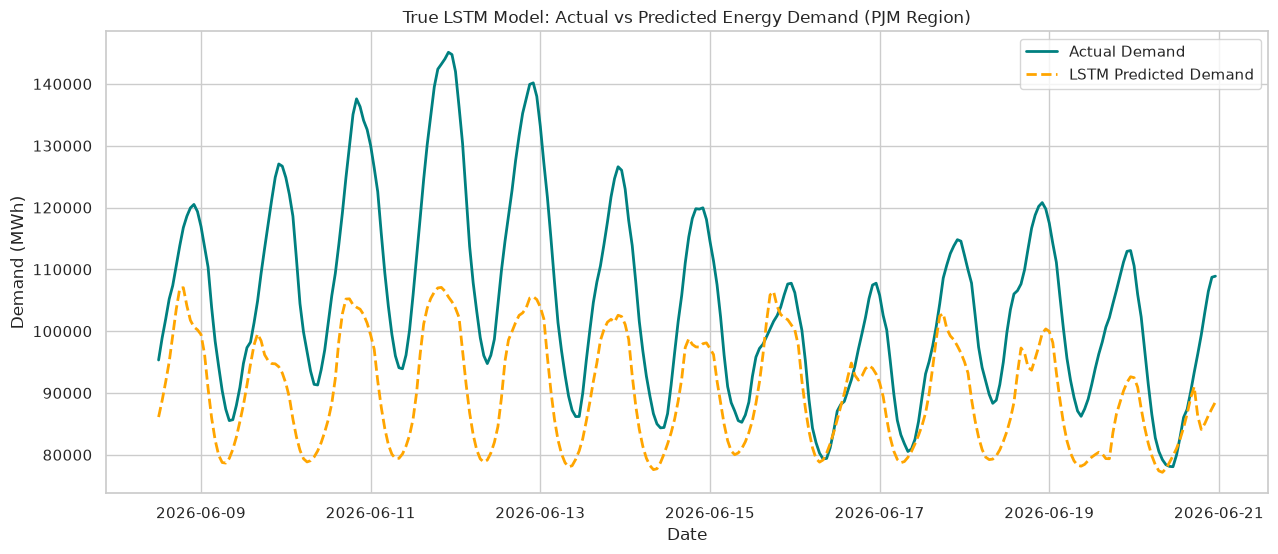

In [8]:
# Plot a subset of the test data (e.g., 300 hours)
plt.figure(figsize=(15, 6))

plot_range = 300
# The time axis needs to account for the seq_length offset
time_axis = region_data.index[train_size + SEQ_LENGTH:][-plot_range:]

plt.plot(time_axis, actual_labels[-plot_range:], label='Actual Demand', color='teal', linewidth=2)
plt.plot(time_axis, actual_predictions[-plot_range:], label='LSTM Predicted Demand', color='orange', linestyle='--', linewidth=2)

plt.title('True LSTM Model: Actual vs Predicted Energy Demand (PJM Region)')
plt.ylabel('Demand (MWh)')
plt.xlabel('Date')
plt.legend()
plt.show()